In [35]:
import pickle as pkl
import os

dt = pkl.load(open("training_data/simple_spiral_data_noisy_120.0s.pkl", "rb"))
print(dt[50])

(array([ 0.32675436, -0.00146413,  0.44753512,  0.004732  , -0.06795306,
       -0.00611717,  0.01060831, -0.16788905, -0.04262199]), array([0.75025997, 1.        , 2.03543938]), array([ 0.32675436, -0.00146413,  0.44753512,  0.004732  , -0.06795306,
       -0.00611717,  0.01060831, -0.16788905, -0.04262199]))


In [36]:
import pickle as pkl
import os

all_data = []
duration = 60.0  # Duration used when collecting data

for left_std in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    for right_std in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
        for servo_std in [0.0, 0.3, 0.6, 0.9, 1.2, 1.5]:
            filename = f"noisy_training_data/noisy_spiral_{left_std}_{right_std}_{servo_std}_{duration}s.pkl"
            
            # Check if file exists before loading
            if os.path.exists(filename):
                try:
                    data = pkl.load(open(filename, "rb"))
                    all_data.extend(data)
                    print(f"Loaded {len(data)} tuples from {filename}")
                except Exception as e:
                    print(f"Error loading {filename}: {e}")
            else:
                print(f"File not found: {filename}")

print(f"\nTotal data tuples collected: {len(all_data)}")

Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.0_0.0_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.0_0.3_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.0_0.6_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.0_0.9_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.0_1.2_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.0_1.5_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.1_0.0_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.1_0.3_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.1_0.6_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.1_0.9_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.1_1.2_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_spiral_0.0_0.1_1.5_60.0s.pkl
Loaded 6001 tuples from noisy_training_data/noisy_sp

In [37]:
import numpy as np
import random

# Shuffle the list - this is the easiest way!
# Shuffling a list is simpler than shuffling tensors
random.shuffle(all_data)

# Or using numpy (same result):
# np.random.shuffle(all_data)

print(f"Shuffled {len(all_data)} data tuples")
print(f"First tuple: state shape={all_data[0][0].shape}, action shape={all_data[0][1].shape}, next_state shape={all_data[0][2].shape}")


Shuffled 1296216 data tuples
First tuple: state shape=(9,), action shape=(3,), next_state shape=(9,)


In [42]:
training_data = all_data[0:350000]
print(len(training_data))
file_name = "350k_training_data_2.pkl"
with open(file_name, "wb") as f:
    pkl.dump(training_data, f)

350000


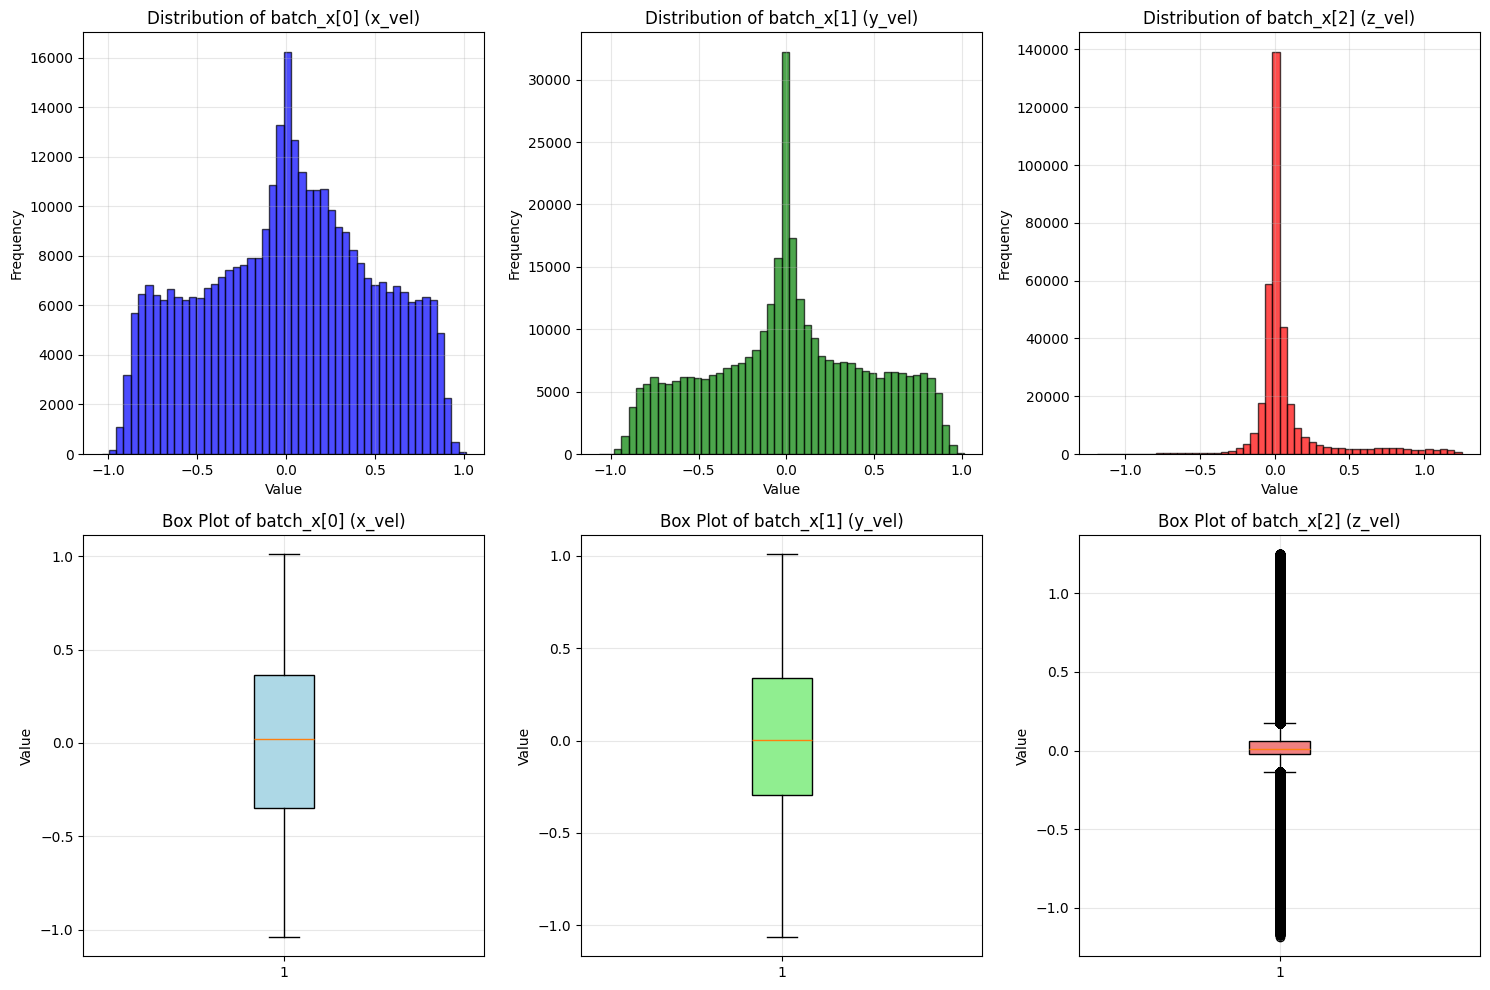

Statistics for batch_x features:
batch_x[0] (x_vel) - Mean: 0.0120, Std: 0.4738, Min: -1.0393, Max: 1.0128
batch_x[1] (y_vel) - Mean: 0.0137, Std: 0.4549, Min: -1.0648, Max: 1.0113
batch_x[2] (z_vel) - Mean: 0.0753, Std: 0.2547, Min: -1.1863, Max: 1.2518


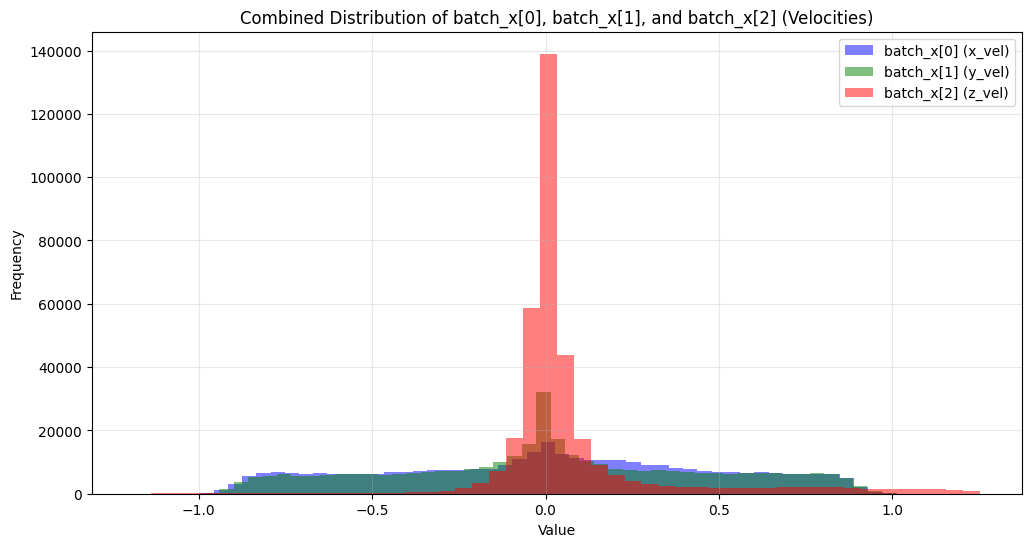

In [43]:
# Plot distributions of batch_x[0], batch_x[1], and batch_x[2] (x_vel, y_vel, z_vel)
import matplotlib.pyplot as plt
import numpy as np
import torch

# ----- Offline training (supervised next-step regression) -----
batch_x_list = []
batch_y_list = []

# Convert training_data format (state, action, next_state) to batch format
for state, action, next_state in training_data:
    obs_tensor = torch.from_numpy(state).float()
    action_tensor = torch.from_numpy(action).float()
    next_obs_tensor = torch.from_numpy(next_state).float()
    
    batch_x_list.append(torch.cat([obs_tensor, action_tensor], dim=-1))
    batch_y_list.append(next_obs_tensor)

# Convert to tensors with correct dimensions
batch_x = torch.stack(batch_x_list, dim=0)  # shape: [B, 12] (9 state + 3 action)
batch_y = torch.stack(batch_y_list, dim=0)

# Extract the data for plotting (first 3 features: x_vel, y_vel, z_vel)
feature_0 = batch_x[:, 0].cpu().numpy()  # x_vel
feature_1 = batch_x[:, 1].cpu().numpy()  # y_vel
feature_2 = batch_x[:, 2].cpu().numpy()  # z_vel

# Create subplots for distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot histograms
axes[0, 0].hist(feature_0, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('Distribution of batch_x[0] (x_vel)')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(feature_1, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_title('Distribution of batch_x[1] (y_vel)')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(feature_2, bins=50, alpha=0.7, color='red', edgecolor='black')
axes[0, 2].set_title('Distribution of batch_x[2] (z_vel)')
axes[0, 2].set_xlabel('Value')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(True, alpha=0.3)

# Plot box plots
axes[1, 0].boxplot(feature_0, patch_artist=True, boxprops=dict(facecolor='lightblue'))
axes[1, 0].set_title('Box Plot of batch_x[0] (x_vel)')
axes[1, 0].set_ylabel('Value')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].boxplot(feature_1, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1, 1].set_title('Box Plot of batch_x[1] (y_vel)')
axes[1, 1].set_ylabel('Value')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].boxplot(feature_2, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
axes[1, 2].set_title('Box Plot of batch_x[2] (z_vel)')
axes[1, 2].set_ylabel('Value')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Statistics for batch_x features:")
print(f"batch_x[0] (x_vel) - Mean: {np.mean(feature_0):.4f}, Std: {np.std(feature_0):.4f}, Min: {np.min(feature_0):.4f}, Max: {np.max(feature_0):.4f}")
print(f"batch_x[1] (y_vel) - Mean: {np.mean(feature_1):.4f}, Std: {np.std(feature_1):.4f}, Min: {np.min(feature_1):.4f}, Max: {np.max(feature_1):.4f}")
print(f"batch_x[2] (z_vel) - Mean: {np.mean(feature_2):.4f}, Std: {np.std(feature_2):.4f}, Min: {np.min(feature_2):.4f}, Max: {np.max(feature_2):.4f}")

# Combined distribution plot
plt.figure(figsize=(12, 6))
plt.hist(feature_0, bins=50, alpha=0.5, label='batch_x[0] (x_vel)', color='blue')
plt.hist(feature_1, bins=50, alpha=0.5, label='batch_x[1] (y_vel)', color='green')
plt.hist(feature_2, bins=50, alpha=0.5, label='batch_x[2] (z_vel)', color='red')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Combined Distribution of batch_x[0], batch_x[1], and batch_x[2] (Velocities)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [44]:
import torch
from saviolo_et_al_mlp import DiscreteQuadDynamicsNN


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sav_model = DiscreteQuadDynamicsNN()
sav_model.to(device)


DiscreteQuadDynamicsNN(
  (fc1): Linear(in_features=13, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=9, bias=True)
  (activation): ELU(alpha=1.0)
)

In [47]:
# Prepare training tensors from training_data (state, action, next_state)
import torch

batch_x_list = []
batch_y_list = []
for state, action, next_state in training_data:
    obs_tensor = torch.from_numpy(state).float()
    action_tensor = torch.from_numpy(action).float()
    next_obs_tensor = torch.from_numpy(next_state).float()
    batch_x_list.append(torch.cat([obs_tensor, action_tensor], dim=-1))
    batch_y_list.append(next_obs_tensor)

batch_x = torch.stack(batch_x_list, dim=0)  # [B, 12]
batch_y = torch.stack(batch_y_list, dim=0)  # [B, 9]

# Pad batch_x with a dummy feature to match model's expected input dim (13)
dummy_feat = torch.zeros(batch_x.shape[0], 1)
batch_x = torch.cat([batch_x, dummy_feat], dim=1)  # [B, 13]

# Move to device
batch_x = batch_x.to(device)
batch_y = batch_y.to(device)

# Compute dataset statistics
x_mean, x_std = batch_x.mean(dim=0), batch_x.std(dim=0)
y_mean, y_std = batch_y.mean(dim=0), batch_y.std(dim=0)
print("x_mean", x_mean, "x_std", x_std, "y_mean", y_mean, "y_std", y_std)

# Avoid division by zero
x_std = x_std.clamp_min(1e-8)
y_std = y_std.clamp_min(1e-8)

# Attach stats if model is available
if 'sav_model' in globals():
    sav_model.attach_stats(x_mean, x_std, y_mean, y_std)

# Normalize
batch_x = (batch_x - x_mean) / x_std
batch_y = (batch_y - y_mean) / y_std

# Split into train/val
N = batch_x.shape[0]
perm = torch.randperm(N, device=batch_x.device)
N_val = max(1, int(0.1 * N))
val_idx = perm[:N_val]
train_idx = perm[N_val:]

batch_x_train = batch_x[train_idx]
batch_y_train = batch_y[train_idx]
batch_x_val   = batch_x[val_idx]
batch_y_val   = batch_y[val_idx]

print("Train set:", batch_x_train.shape, batch_y_train.shape)
print("Val set:", batch_x_val.shape, batch_y_val.shape)


x_mean tensor([ 0.0120,  0.0137,  0.0753, -0.0010, -0.1062,  0.0283, -0.0003, -0.0017,
         0.0174,  0.2782,  0.2830,  0.0517,  0.0000], device='cuda:0') x_std tensor([0.4738, 0.4549, 0.2547, 0.0195, 0.0743, 1.7451, 0.0956, 0.1261, 0.2202,
        0.2596, 0.2617, 0.9810, 0.0000], device='cuda:0') y_mean tensor([ 0.0120,  0.0137,  0.0753, -0.0010, -0.1062,  0.0283, -0.0003, -0.0017,
         0.0174], device='cuda:0') y_std tensor([0.4738, 0.4549, 0.2547, 0.0195, 0.0743, 1.7451, 0.0956, 0.1261, 0.2202],
       device='cuda:0')
Train set: torch.Size([315000, 13]) torch.Size([315000, 9])
Val set: torch.Size([35000, 13]) torch.Size([35000, 9])


In [ ]:
all_data

In [ ]:
# ----- Training -----
import torch

opt = torch.optim.Adam(sav_model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="min", factor=0.5, patience=25, min_lr=1e-9, verbose=True
)

batch_size = 1024

def compute_validation_loss():
    sav_model.eval()
    with torch.no_grad():
        Nval = batch_x_val.shape[0]
        total, count = 0.0, 0
        for s in range(0, Nval, batch_size):
            e = min(s + batch_size, Nval)
            stats = sav_model.supervised_step(batch_x_val[s:e], batch_y_val[s:e], None)
            bsz = e - s
            total += stats["loss"] * bsz   # assume mean loss returned
            count += bsz
        return total / max(1, count)

print("Starting training...")
for epoch in range(10000):  # paper reports ~20K epochs
    sav_model.train()

    # Shuffle train set
    Ntr = batch_x_train.shape[0]
    idx = torch.randperm(Ntr, device=batch_x_train.device)
    x_shuf = batch_x_train.index_select(0, idx)
    y_shuf = batch_y_train.index_select(0, idx)

    # Mini-batch training (NO tail drop + sample-weighted averaging)
    total_train, rpy_loss, lv_loss, w_loss, count_train = 0.0, 0.0, 0.0, 0.0, 0
    for s in range(0, Ntr, batch_size):
        e = min(s + batch_size, Ntr)
        stats = sav_model.supervised_step(x_shuf[s:e], y_shuf[s:e], opt)
        bsz = e - s
        total_train += stats["loss"] * bsz
        rpy_loss += stats.get("lq", 0.0) * bsz
        lv_loss += stats.get("lv", 0.0) * bsz
        w_loss  += stats.get("lw", 0.0) * bsz
        count_train += bsz
    avg_train_loss = total_train / max(1, count_train)
    avg_rpy_loss   = rpy_loss   / max(1, count_train)
    avg_lv_loss    = lv_loss    / max(1, count_train)
    avg_w_loss     = w_loss     / max(1, count_train)

    # Validation + scheduler
    val_loss = compute_validation_loss()
    scheduler.step(val_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:4d} | Train {avg_train_loss:.9f} | lv {avg_lv_loss:.9f} | w {avg_w_loss:.9f} | rpy {avg_rpy_loss:.9f} | Val {val_loss:.6f} | "
              f"LR {opt.param_groups[0]['lr']:.2e}")


Starting training...
Epoch    0 | Train 0.208705610 | lv 0.067336015 | w 0.066057482 | rpy 0.075312113 | Val 0.010957 | LR 1.00e-03
Epoch   50 | Train 0.000087920 | lv 0.000024130 | w 0.000025836 | rpy 0.000037954 | Val 0.000078 | LR 1.00e-03
Epoch  100 | Train 0.000062067 | lv 0.000017585 | w 0.000017826 | rpy 0.000026656 | Val 0.000102 | LR 1.00e-03
